# Israeli Actors Graph — Data Collection

**Goal:** collect Israeli films and their cast lists from Hebrew Wikipedia's
[Israeli films list](https://he.wikipedia.org/wiki/סרטי_קולנוע_ישראליים) page,
as the raw material for the actor co-appearance graph.

**Method:** the source page is a single *list article* organized into ~10
decade-by-decade tables, not a raw MediaWiki category. Each table row already
has year, title, screenwriter(s), director(s), a cast column, genre, awards,
and notes — so a single page fetch (via the MediaWiki API) gives us
everything needed, with **no per-film or per-actor page visits required**.
Actors are keyed by their Wikipedia page slug when a cast name is wikilinked
(canonical, dedup-safe), falling back to normalized display text otherwise.


In [1]:
import os
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
import scraping

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout.reconfigure(encoding="utf-8")

plt.rcParams["font.family"] = "Arial"  # better Hebrew glyph coverage than the default

## Fetch & parse the list page

In [2]:
records = scraping.collect_movie_list()  # cached on disk after the first fetch
movies = pd.DataFrame(records)

# Link-list columns (screenwriters/directors/cast_from_list) come back as
# actual Python lists; JSON-encode them to strings so this DataFrame matches
# the on-disk CSV format used everywhere downstream (movies.csv, cast_edges
# construction), and round-trips through pd.read_csv unchanged.
for col in ["screenwriters", "directors", "cast_from_list"]:
    movies[col] = movies[col].apply(lambda x: json.dumps(x, ensure_ascii=False))

movies["cast_count"] = movies["cast_from_list"].apply(lambda x: len(json.loads(x)))
print(f"{len(movies)} film rows parsed ({movies['title'].nunique()} unique titles).")
movies.head(10)[["title", "year", "genre", "cast_count"]]

840 film rows parsed (833 unique titles).


,title,year,genre,cast_count
0,יהודה המשוחררתאו ארץ ישראל המשוחררת,1918,תיעודי,0
1,שיבת ציון (סרט),1920,,0
2,ארץ ישראל המתחדשת,1921,,0
3,"מעשה בתייר אמריקאי בא""י",1923,,0
4,בנים בונים,1924,,0
5,התיבה,1927,,0
6,אביב בארץ ישראל,1928,תיעודי,0
7,הרפתקאותיו של גדי בן סוסי,1931,,0
8,יומן ארץ ישראל,1932,,0
9,צבר,1933,,6


## Films over time

The list spans 1918 through the present. Binning by 5-year buckets makes the
growth of Israeli film production visible at a glance.

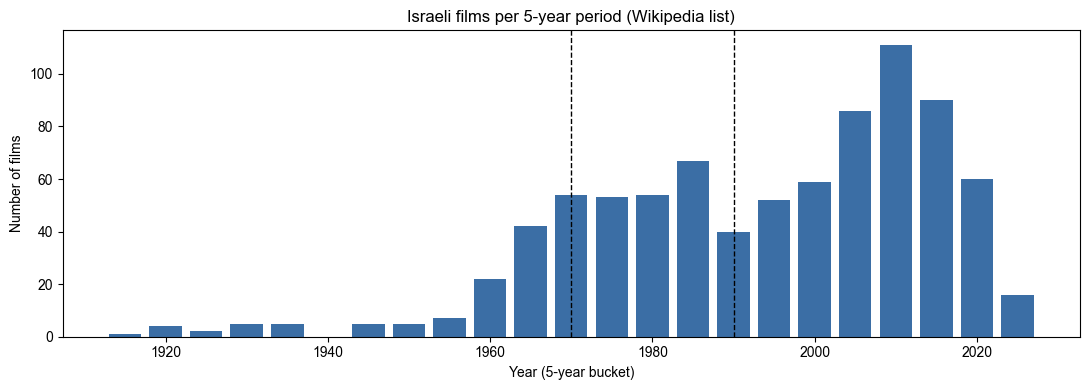

In [3]:
bucket = (movies["year"] // 5 * 5).astype(int)
counts = bucket.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(counts.index, counts.values, width=4, color="#3b6ea5")
ax.set_xlabel("Year (5-year bucket)")
ax.set_ylabel("Number of films")
ax.set_title("Israeli films per 5-year period (Wikipedia list)")
for boundary in (1970, 1990):
    ax.axvline(boundary, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [4]:
def period_of_year(y):
    if y <= 1970:
        return "A (<=1970)"
    if y <= 1990:
        return "B (1970-1990)"
    return "C (>1990)"

movies["period"] = movies["year"].apply(period_of_year)
period_counts = movies["period"].value_counts().sort_index()
period_counts

period
A (<=1970)       106
B (1970-1990)    226
C (>1990)        508
Name: count, dtype: int64

## Genre distribution

Genre is free-text as entered on Wikipedia, so this is a coarse look — some
films have no genre listed at all.

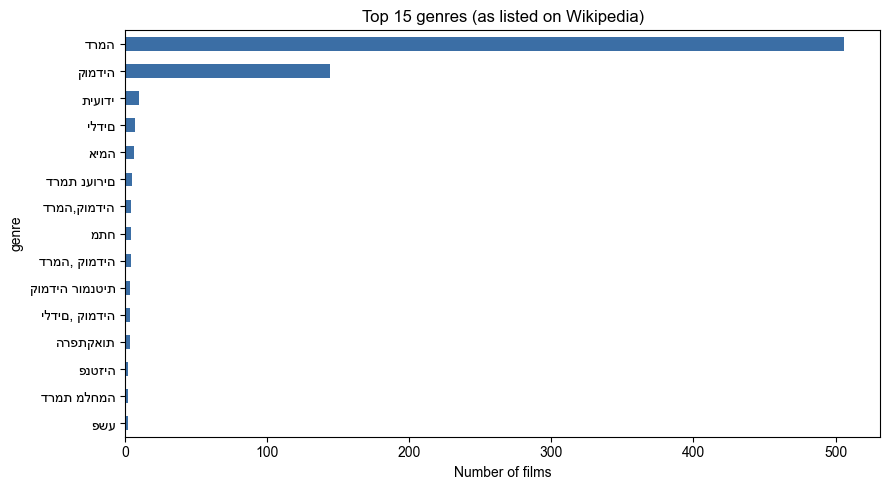

In [5]:
genre_counts = movies.loc[movies["genre"].str.len() > 0, "genre"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
genre_counts.sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Number of films")
ax.set_title("Top 15 genres (as listed on Wikipedia)")
plt.tight_layout()
plt.show()

## Cast list size per film

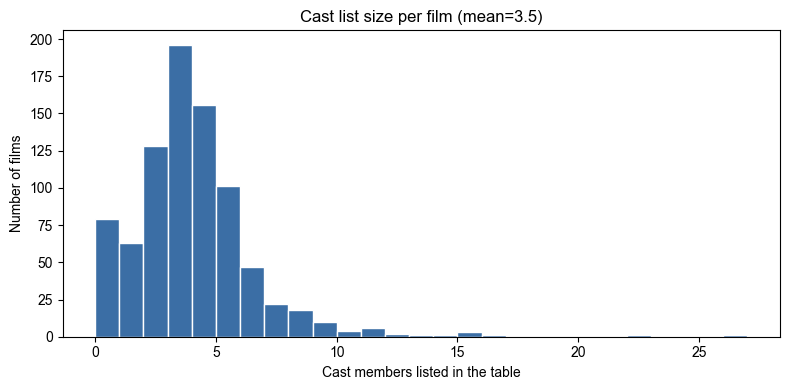

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
movies["cast_count"].plot(kind="hist", bins=range(0, movies["cast_count"].max() + 2), ax=ax, color="#3b6ea5", edgecolor="white")
ax.set_xlabel("Cast members listed in the table")
ax.set_ylabel("Number of films")
ax.set_title(f"Cast list size per film (mean={movies['cast_count'].mean():.1f})")
plt.tight_layout()
plt.show()

## Data quality notes

- **Duplicate/near-duplicate titles**: 840 rows but only 833 unique titles.
- **No article page (`wiki_slug` is null)**: the film is named on the list
  but has no Wikipedia article of its own. This does **not** block cast
  extraction — the cast column lives in the list table itself.
- **Empty cast cell**: a film may have a page (or not) but simply list no
  cast in the table. These contribute no edges to the graph.

In [7]:
n_no_slug = movies["wiki_slug"].isna().sum()
n_no_cast = (movies["cast_count"] == 0).sum()
n_dupe_titles = len(movies) - movies["title"].nunique()

print(f"Rows without a wiki_slug (no article page): {n_no_slug} / {len(movies)}")
print(f"Rows with an empty cast column:              {n_no_cast} / {len(movies)}")
print(f"Duplicate title rows:                        {n_dupe_titles}")

Rows without a wiki_slug (no article page): 95 / 840
Rows with an empty cast column:              79 / 840
Duplicate title rows:                        7


## Building the actor-credit table

Each row of `cast_edges` is one (film, actor) credit — the raw material for
the co-appearance graph built in the next notebook.

In [8]:
cast_edges = scraping.build_cast_edges_from_movie_list(movies)
print(f"{len(cast_edges)} cast rows across {cast_edges['movie_slug'].nunique()} films, "
      f"{cast_edges['actor_slug'].fillna(cast_edges['actor_name']).nunique()} unique actors.")
cast_edges.head(10)

2972 cast rows across 759 films, 1398 unique actors.


,movie_slug,movie_title,year,genre,directors,cast_source,billing_position,actor_name,actor_slug
0,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,0,רפאל קלצ'קין,רפאל_קלצ'קין
1,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,1,אהרן מסקין,אהרן_מסקין
2,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,2,שמעון פינקל,שמעון_פינקל
3,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,3,חנה רובינא,חנה_רובינא
4,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,4,יהושע ברטונוב,יהושע_ברטונוב
5,צבר_(סרט),צבר,1933,,"[{""name"": ""אלכסנדר פורד"", ""slug"": ""אלכסנדר_פור...",list_table,5,פסח בר אדון,פסח_בר_אדון
6,__title__:אין זו אגדה__1949,אין זו אגדה,1949,,"[{""name"": ""יוסף קרומגולד"", ""slug"": null}]",list_table,0,חווה אלפרשטיין (אגמון),None
7,__title__:אין זו אגדה__1949,אין זו אגדה,1949,,"[{""name"": ""יוסף קרומגולד"", ""slug"": null}]",list_table,1,אברהם סורוקה-דוריון,None
8,__title__:אין זו אגדה__1949,אין זו אגדה,1949,,"[{""name"": ""יוסף קרומגולד"", ""slug"": null}]",list_table,2,יהודה בן-משה,None
9,עיר_האוהלים,עיר האוהלים (Tent City),1951,דוקו-דרמה,"[{""name"": ""אריה להולה"", ""slug"": ""אריה_להולה""}]",list_table,0,אורנה פורת,אורנה_פורת


## Most prolific actors (by number of film credits in this dataset)

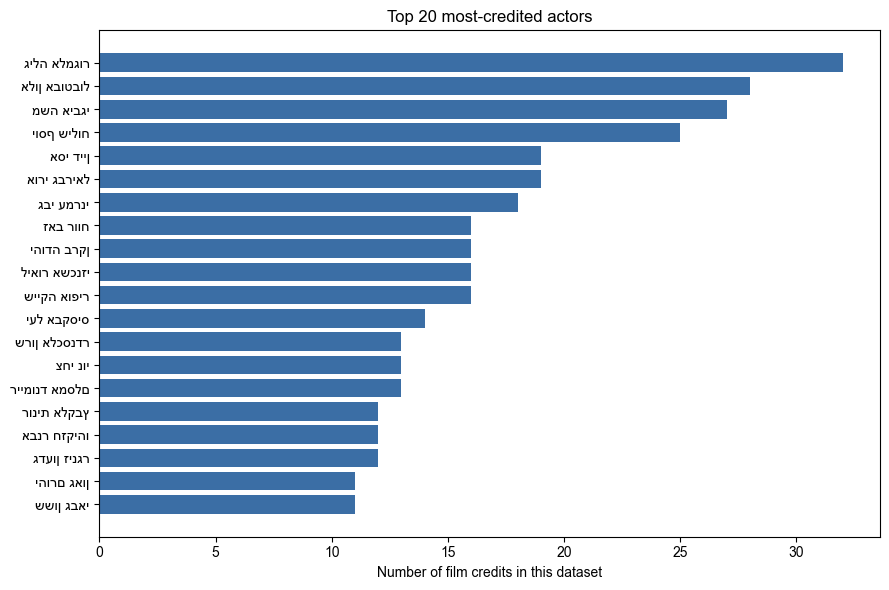

In [9]:
actor_key = cast_edges["actor_slug"].fillna(cast_edges["actor_name"])
top_actors = (
    cast_edges.assign(actor_key=actor_key)
    .groupby(["actor_key", "actor_name"])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="n_films")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_actors["actor_name"][::-1], top_actors["n_films"][::-1], color="#3b6ea5")
ax.set_xlabel("Number of film credits in this dataset")
ax.set_title("Top 20 most-credited actors")
plt.tight_layout()
plt.show()

In [10]:
try:
    movies.to_csv("../data/processed/movies.csv", index=False, encoding="utf-8-sig")
    cast_edges.to_csv("../data/processed/cast_edges.csv", index=False, encoding="utf-8-sig")
    print("Saved movies.csv and cast_edges.csv to data/processed/")
except PermissionError:
    print("Could not overwrite movies.csv/cast_edges.csv (likely open in another "
          "program, e.g. Excel) -- skipping save; on-disk copies are unchanged.")

Could not overwrite movies.csv/cast_edges.csv (likely open in another program, e.g. Excel) -- skipping save; on-disk copies are unchanged.


## Next step

`02_graph_construction.ipynb` turns `cast_edges.csv` into the actor
co-appearance graph and splits it into the three analysis periods.